# 03 - Exploratory Data Analysis


**Tasks**:
- Descriptive statistics per ticker
- Price and return distributions
- Volatility analysis
- Fundamental trends
- Options data exploration
- Correlation analysis

**Output**: Insights and visualizations for feature engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load cleaned data
PROCESSED = Path('../data/processed')

daily = pd.read_parquet(PROCESSED / 'daily_clean.parquet')
income = pd.read_parquet(PROCESSED / 'income_clean.parquet')
balance = pd.read_parquet(PROCESSED / 'balance_clean.parquet')
cashflow = pd.read_parquet(PROCESSED / 'cashflow_clean.parquet')
options = pd.read_parquet(PROCESSED / 'options_clean.parquet')
overview = pd.read_parquet(PROCESSED / 'overview_clean.parquet')

print("Data loaded successfully!")

Data loaded successfully!


## 1. Price Analysis

In [2]:
# Descriptive statistics per ticker
price_stats = daily.groupby('symbol')['adjusted_close'].agg(['min', 'max', 'mean', 'std', 'count'])
price_stats['range'] = price_stats['max'] - price_stats['min']
price_stats = price_stats.round(2)
print("Price Statistics by Ticker:")
price_stats

Price Statistics by Ticker:


,min,max,mean,std,count,range
symbol,,,,,,
AAPL,20.58,285.92,106.23,74.26,2766,265.34
ADMA,1.09,24.51,6.24,5.13,2766,23.42
AMZN,14.35,254.00,111.76,61.73,2766,239.65
AXON,14.50,870.97,163.59,191.87,2766,856.47
GOOG,24.44,323.42,93.90,58.27,2766,298.98
META,73.54,788.82,261.27,173.91,2766,715.28
MSFT,34.36,539.81,205.70,142.97,2766,505.45
NTRA,6.61,244.55,57.87,52.37,2641,237.94
NVDA,0.46,207.03,32.81,49.86,2766,206.57


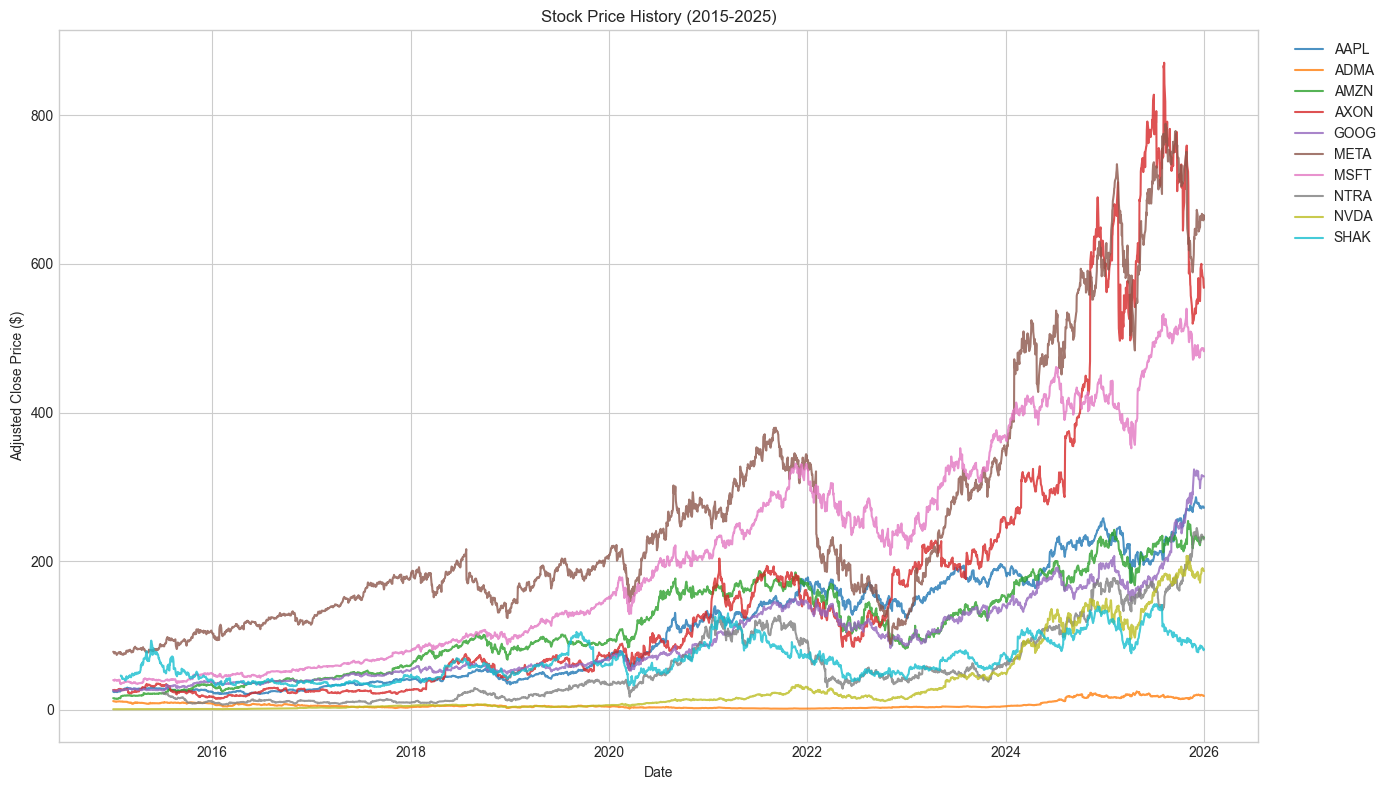

In [3]:
# Price history plot
fig, ax = plt.subplots(figsize=(14, 8))

for ticker in daily['symbol'].unique():
    subset = daily[daily['symbol'] == ticker]
    ax.plot(subset['date'], subset['adjusted_close'], label=ticker, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close Price ($)')
ax.set_title('Stock Price History (2015-2025)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

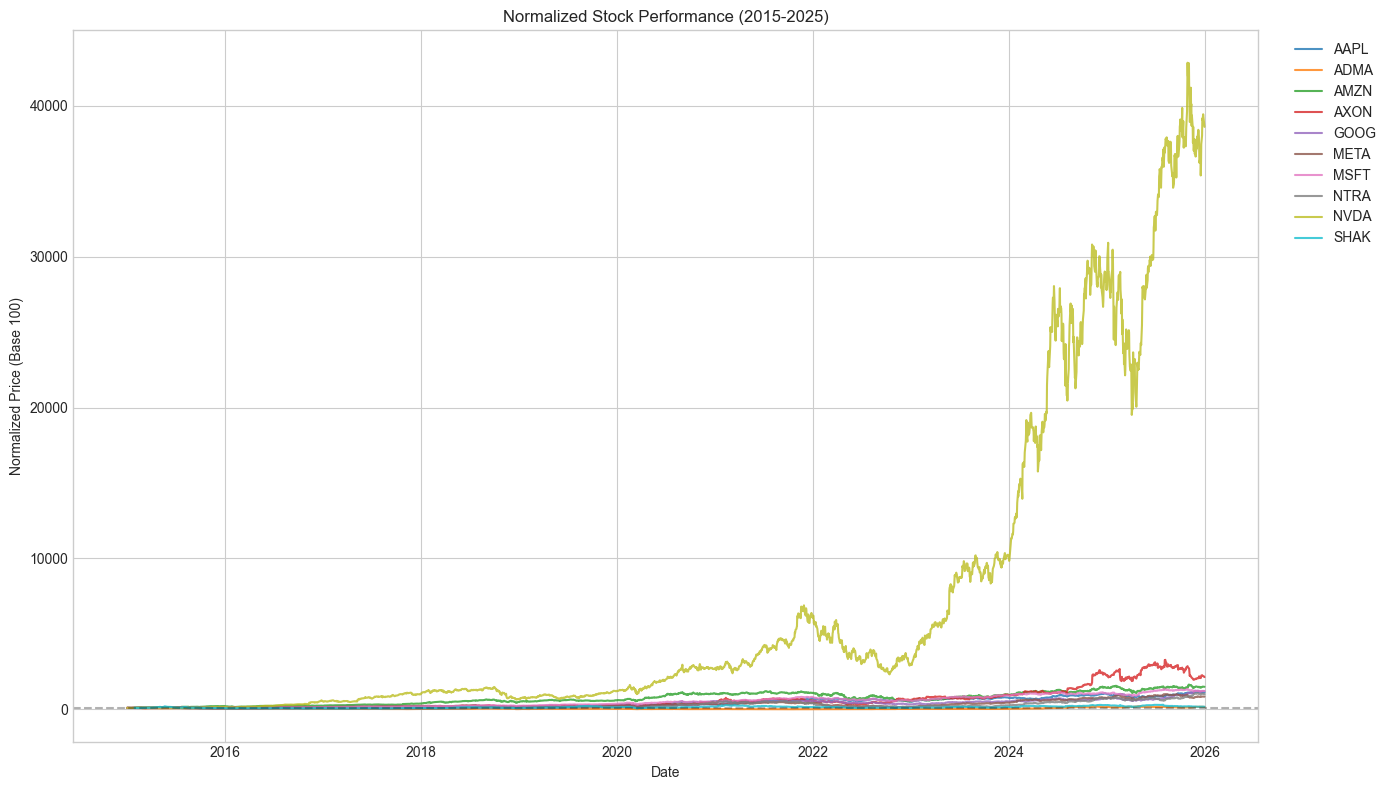

In [4]:
# Normalized price (base 100) for comparison
fig, ax = plt.subplots(figsize=(14, 8))

for ticker in daily['symbol'].unique():
    subset = daily[daily['symbol'] == ticker].copy()
    subset['normalized'] = subset['adjusted_close'] / subset['adjusted_close'].iloc[0] * 100
    ax.plot(subset['date'], subset['normalized'], label=ticker, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price (Base 100)')
ax.set_title('Normalized Stock Performance (2015-2025)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
ax.axhline(y=100, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Returns Analysis

In [5]:
# Calculate daily returns
daily['return'] = daily.groupby('symbol')['adjusted_close'].pct_change()

# Return statistics
return_stats = daily.groupby('symbol')['return'].agg(['mean', 'std', 'min', 'max', 'skew']).round(4)
return_stats['sharpe'] = (return_stats['mean'] / return_stats['std'] * np.sqrt(252)).round(2)
print("Daily Return Statistics:")
return_stats

Daily Return Statistics:


,mean,std,min,max,skew,sharpe
symbol,,,,,,
AAPL,0.0010,0.0182,-0.1286,0.1533,0.1400,0.87
ADMA,0.0011,0.0422,-0.4561,0.4067,0.8052,0.41
AMZN,0.0012,0.0207,-0.1405,0.1413,0.4148,0.92
AXON,0.0016,0.0305,-0.1642,0.2868,1.0220,0.83
GOOG,0.0011,0.0182,-0.1110,0.1605,0.2785,0.96
META,0.0011,0.0236,-0.2639,0.2328,-0.2421,0.74
MSFT,0.0010,0.0169,-0.1474,0.1422,0.1577,0.94
NTRA,0.0016,0.0388,-0.3279,0.3995,0.4734,0.65
NVDA,0.0026,0.0307,-0.1876,0.2981,0.5588,1.34


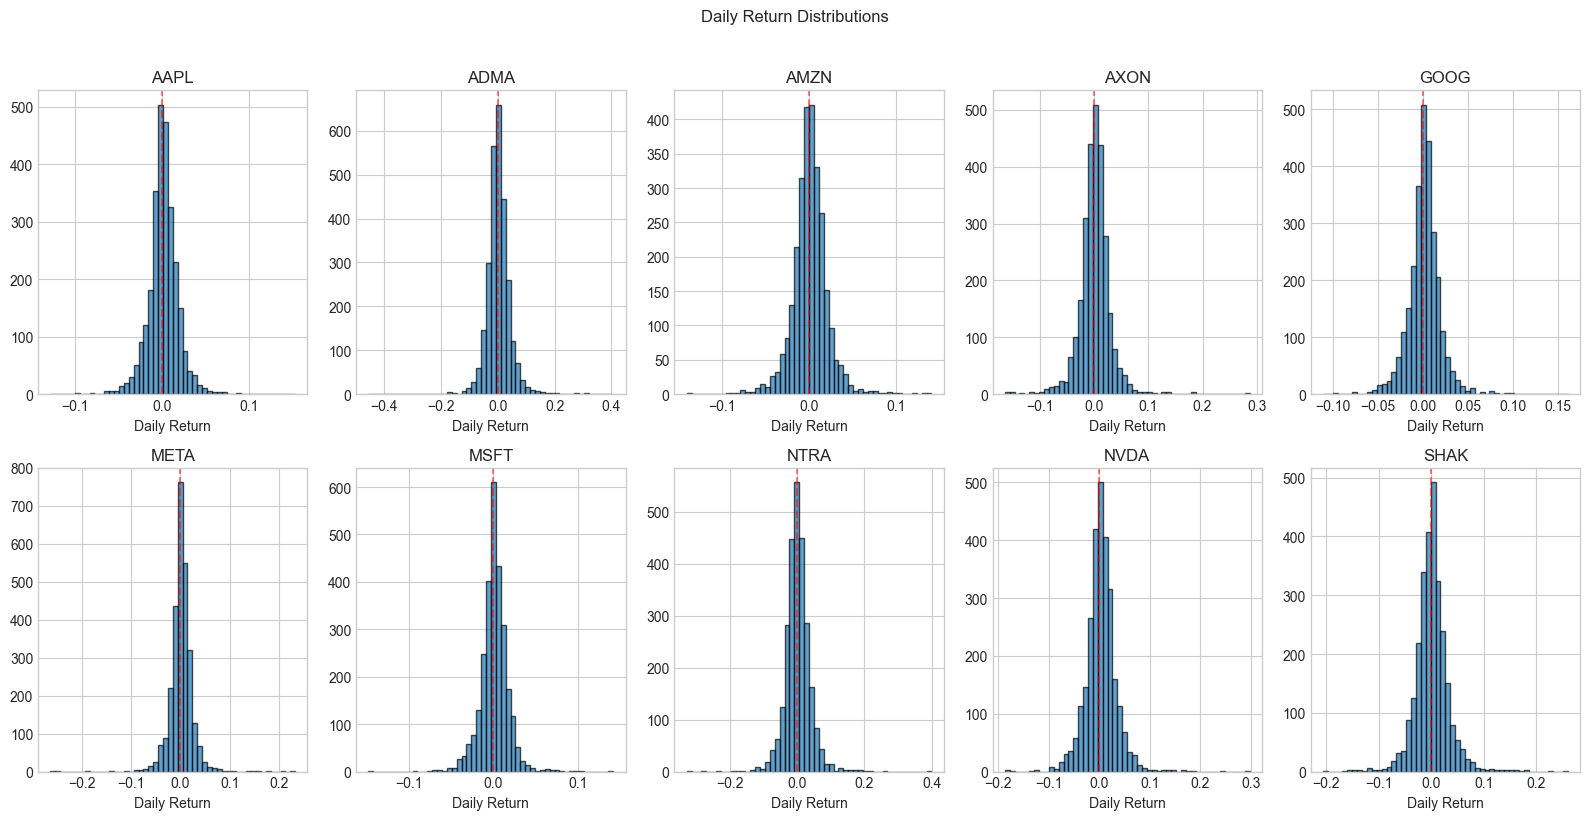

In [6]:
# Return distribution by ticker
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
axes = axes.flatten()

for i, ticker in enumerate(daily['symbol'].unique()):
    subset = daily[daily['symbol'] == ticker]['return'].dropna()
    axes[i].hist(subset, bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{ticker}')
    axes[i].set_xlabel('Daily Return')
    axes[i].axvline(x=0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Daily Return Distributions', y=1.02)
plt.tight_layout()
plt.show()

## 3. Volatility Analysis

In [7]:
# Calculate rolling volatility (30-day)
daily['volatility_30d'] = daily.groupby('symbol')['return'].transform(
    lambda x: x.rolling(window=30).std() * np.sqrt(252)
)

# Calculate rolling volatility (60-day)
daily['volatility_60d'] = daily.groupby('symbol')['return'].transform(
    lambda x: x.rolling(window=60).std() * np.sqrt(252)
)

# Volatility statistics
vol_stats = daily.groupby('symbol')['volatility_30d'].agg(['mean', 'std', 'min', 'max']).round(4)
print("30-Day Annualized Volatility Statistics:")
vol_stats

30-Day Annualized Volatility Statistics:


,mean,std,min,max
symbol,,,,
AAPL,0.2643,0.1175,0.0807,0.9560
ADMA,0.6194,0.2700,0.1874,2.1716
AMZN,0.3058,0.1249,0.0818,0.6842
AXON,0.4490,0.1832,0.1356,1.1713
GOOG,0.2695,0.1072,0.0671,0.7930
META,0.3390,0.1662,0.0703,0.9656
MSFT,0.2458,0.1133,0.0661,0.9975
NTRA,0.5741,0.2325,0.2083,1.9237
NVDA,0.4553,0.1790,0.1755,1.2163


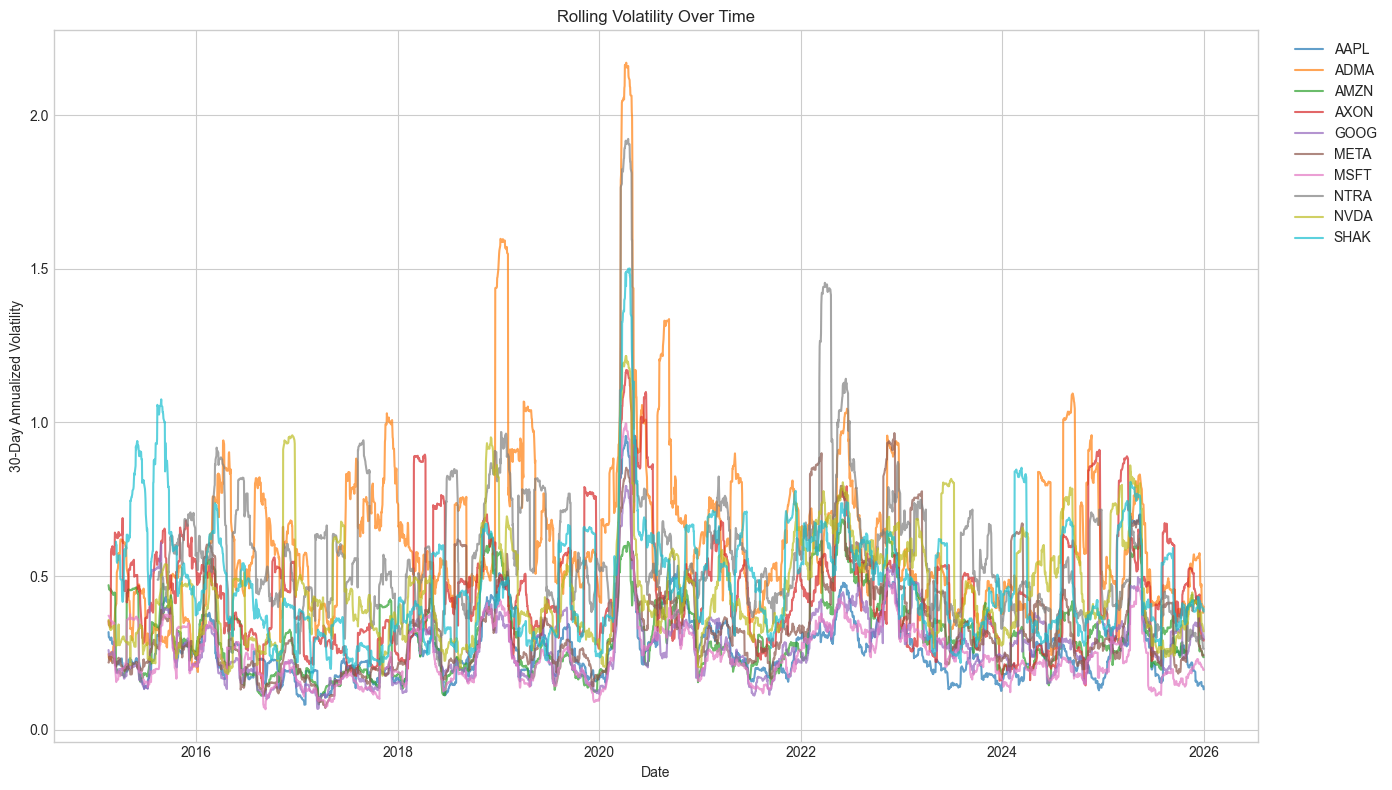

In [8]:
# Volatility over time
fig, ax = plt.subplots(figsize=(14, 8))

for ticker in daily['symbol'].unique():
    subset = daily[daily['symbol'] == ticker]
    ax.plot(subset['date'], subset['volatility_30d'], label=ticker, alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('30-Day Annualized Volatility')
ax.set_title('Rolling Volatility Over Time')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/mk/9dr18q3j66b6915fh7r119pm0000gn/T/ipykernel_3598/206960246.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vol_data, labels=daily['symbol'].unique())


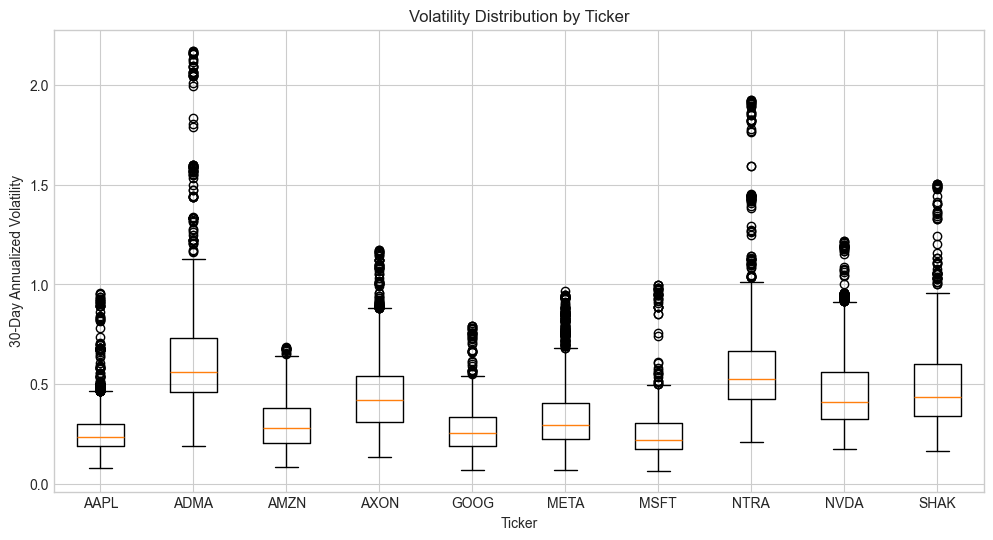

In [9]:
# Volatility distribution boxplot
fig, ax = plt.subplots(figsize=(12, 6))

vol_data = [daily[daily['symbol'] == ticker]['volatility_30d'].dropna() for ticker in daily['symbol'].unique()]
ax.boxplot(vol_data, labels=daily['symbol'].unique())
ax.set_xlabel('Ticker')
ax.set_ylabel('30-Day Annualized Volatility')
ax.set_title('Volatility Distribution by Ticker')
plt.show()

## 4. Fundamental Analysis

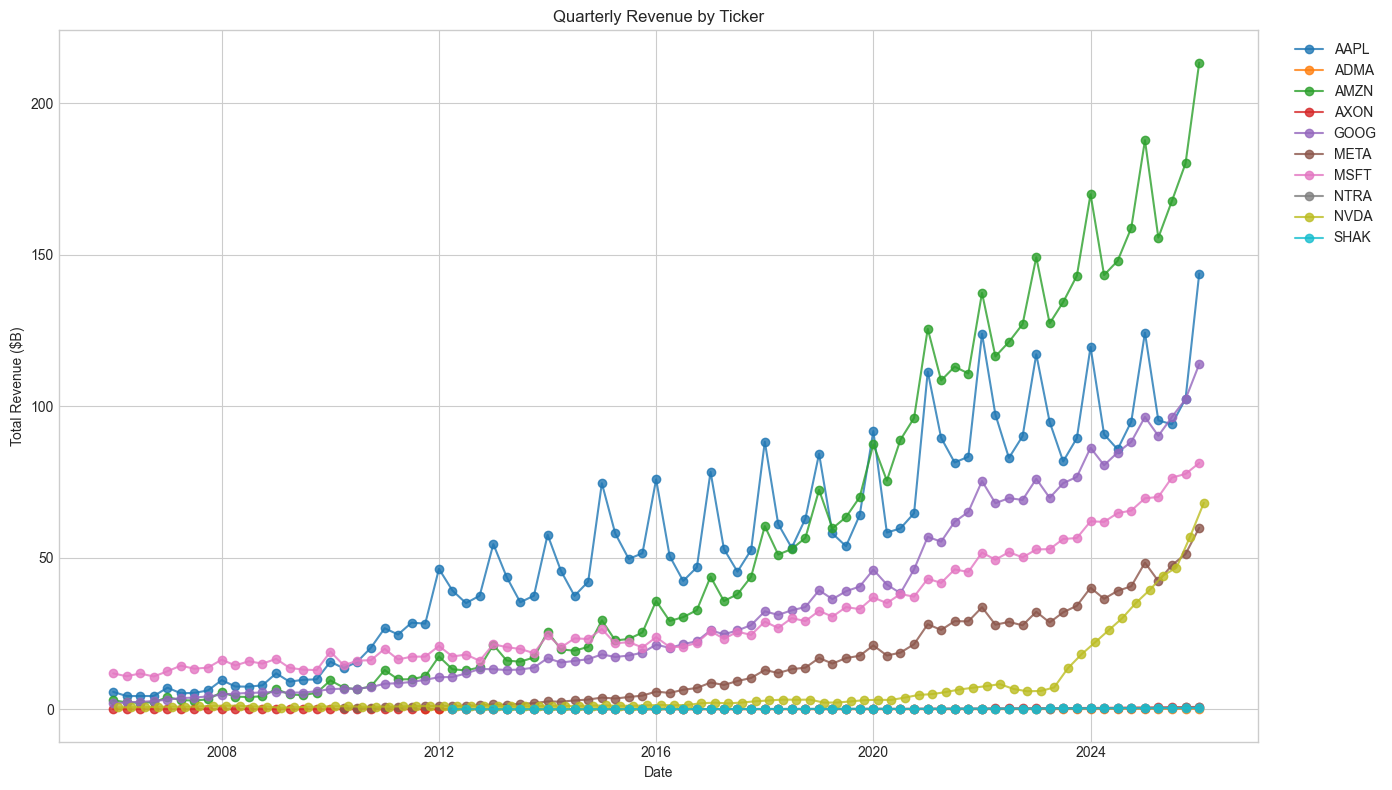

In [10]:
# Revenue trends
fig, ax = plt.subplots(figsize=(14, 8))

for ticker in income['symbol'].unique():
    subset = income[income['symbol'] == ticker].sort_values('fiscalDateEnding')
    ax.plot(subset['fiscalDateEnding'], subset['totalRevenue'] / 1e9, marker='o', label=ticker, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Total Revenue ($B)')
ax.set_title('Quarterly Revenue by Ticker')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

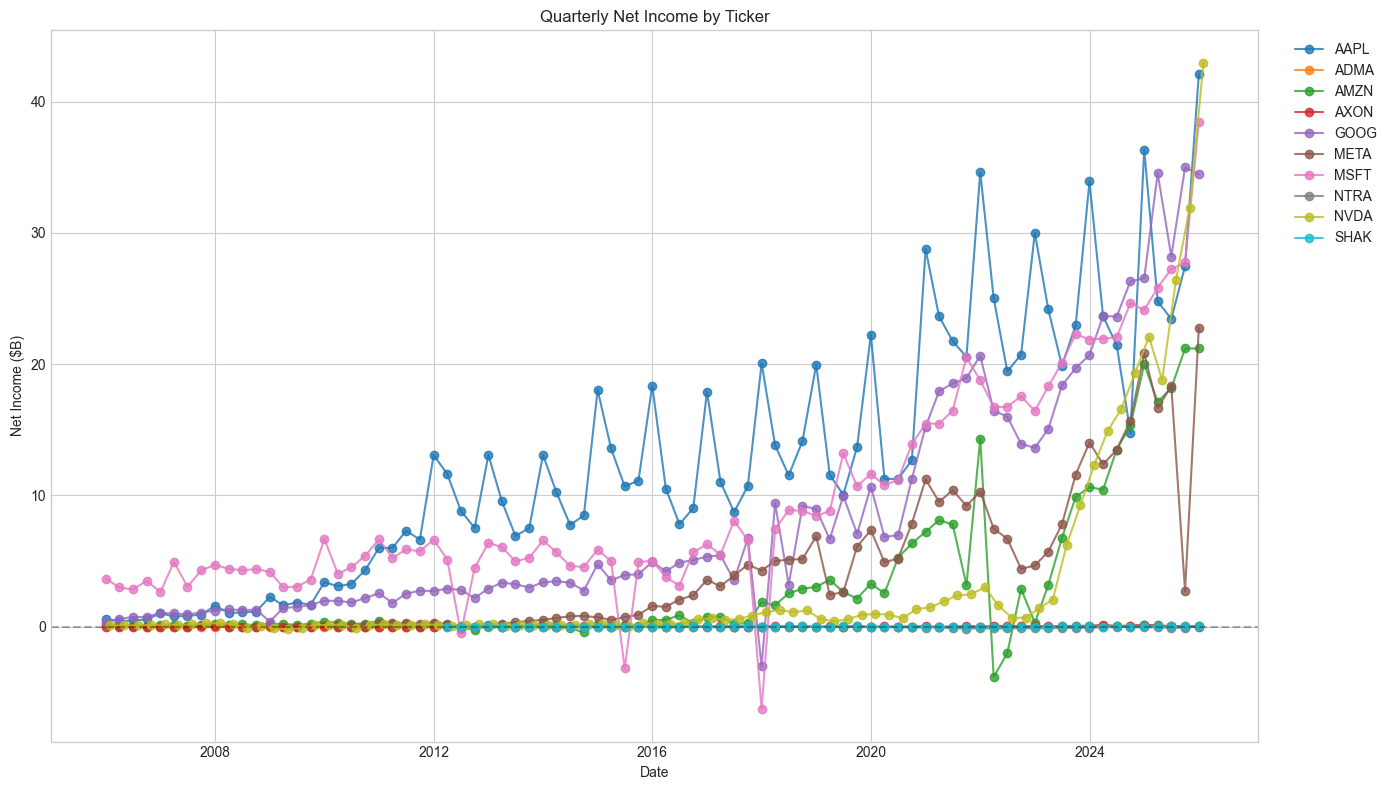

In [11]:
# Net Income trends
fig, ax = plt.subplots(figsize=(14, 8))

for ticker in income['symbol'].unique():
    subset = income[income['symbol'] == ticker].sort_values('fiscalDateEnding')
    ax.plot(subset['fiscalDateEnding'], subset['netIncome'] / 1e9, marker='o', label=ticker, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Net Income ($B)')
ax.set_title('Quarterly Net Income by Ticker')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# Gross margin by ticker
income['gross_margin'] = income['grossProfit'] / income['totalRevenue']

margin_stats = income.groupby('symbol')['gross_margin'].agg(['mean', 'std', 'min', 'max']).round(4)
print("Gross Margin Statistics:")
margin_stats

Gross Margin Statistics:


,mean,std,min,max
symbol,,,,
AAPL,0.3965,0.0430,0.2720,0.4816
ADMA,-inf,NaN,-inf,1.0000
AMZN,0.2774,0.1774,-0.4326,0.5181
AXON,0.6030,0.0501,0.3271,0.7460
GOOG,0.5942,0.0320,0.5155,0.6576
META,0.7930,0.2528,0.0000,2.2192
MSFT,0.7146,0.0643,0.5851,0.8514
NTRA,0.4333,0.1559,-0.3014,0.6714
NVDA,0.5508,0.1271,0.1655,0.7835


## 5. Options Data Analysis

In [13]:
# Filter to calls only (for covered call analysis)
calls = options[options['call_put'] == 'CALL'].copy()
print(f"Total call options: {len(calls):,}")
print(f"\nCalls per ticker:")
print(calls.groupby('symbol').size())

Total call options: 328,707

Calls per ticker:
symbol
AAPL    34297
ADMA      890
AMZN    88323
AXON     3544
GOOG    69560
META    22542
MSFT    33247
NTRA     2220
NVDA    51348
SHAK    22736
dtype: int64


/var/folders/mk/9dr18q3j66b6915fh7r119pm0000gn/T/ipykernel_3598/711034158.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(iv_data, labels=calls['symbol'].unique())


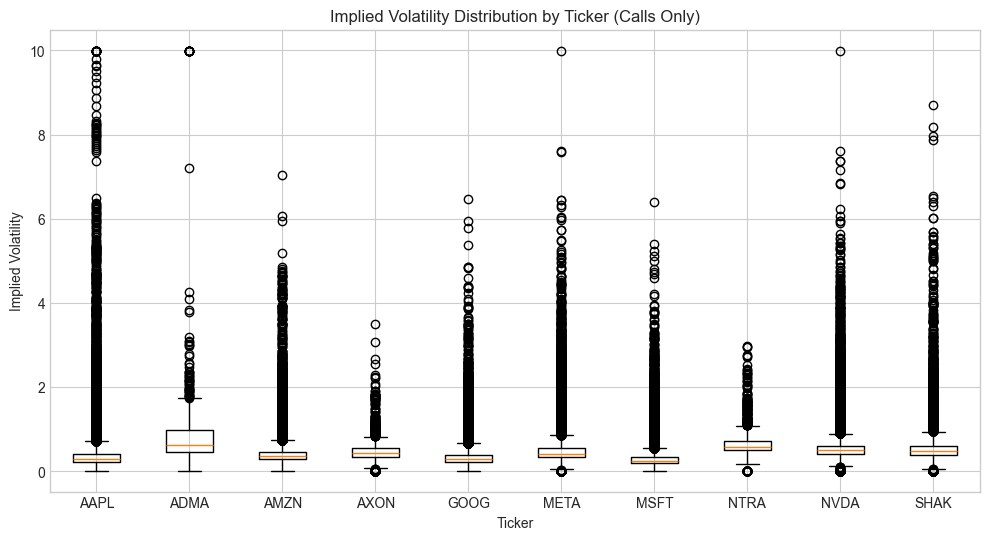

In [14]:
# Implied volatility distribution
fig, ax = plt.subplots(figsize=(12, 6))

iv_data = [calls[calls['symbol'] == ticker]['implied_vol'].dropna() for ticker in calls['symbol'].unique()]
ax.boxplot(iv_data, labels=calls['symbol'].unique())
ax.set_xlabel('Ticker')
ax.set_ylabel('Implied Volatility')
ax.set_title('Implied Volatility Distribution by Ticker (Calls Only)')
plt.show()

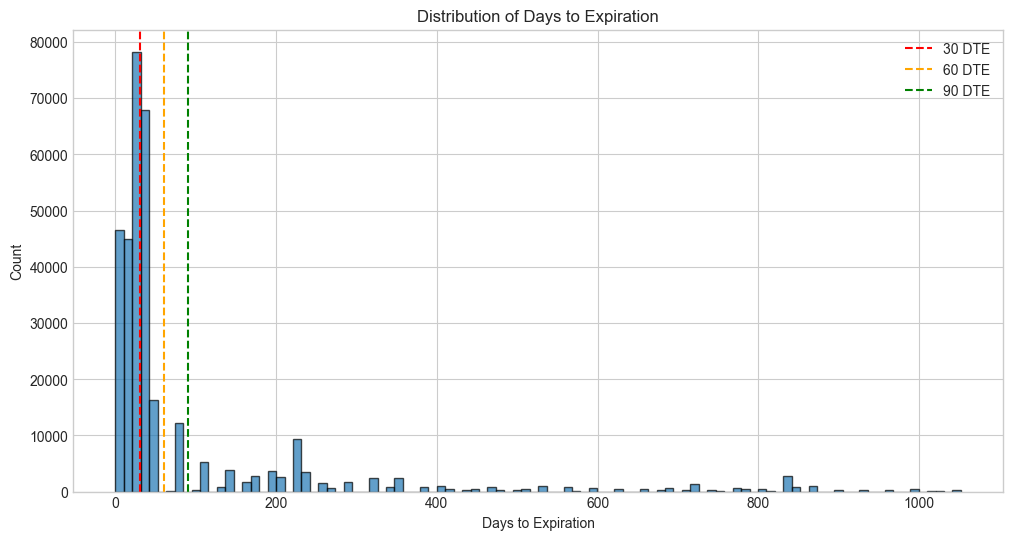

In [15]:
# Days to expiration distribution
calls['dte'] = (calls['expiration'] - calls['trade_date']).dt.days

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(calls['dte'], bins=100, edgecolor='black', alpha=0.7)
ax.set_xlabel('Days to Expiration')
ax.set_ylabel('Count')
ax.set_title('Distribution of Days to Expiration')
ax.axvline(x=30, color='red', linestyle='--', label='30 DTE')
ax.axvline(x=60, color='orange', linestyle='--', label='60 DTE')
ax.axvline(x=90, color='green', linestyle='--', label='90 DTE')
ax.legend()
plt.show()

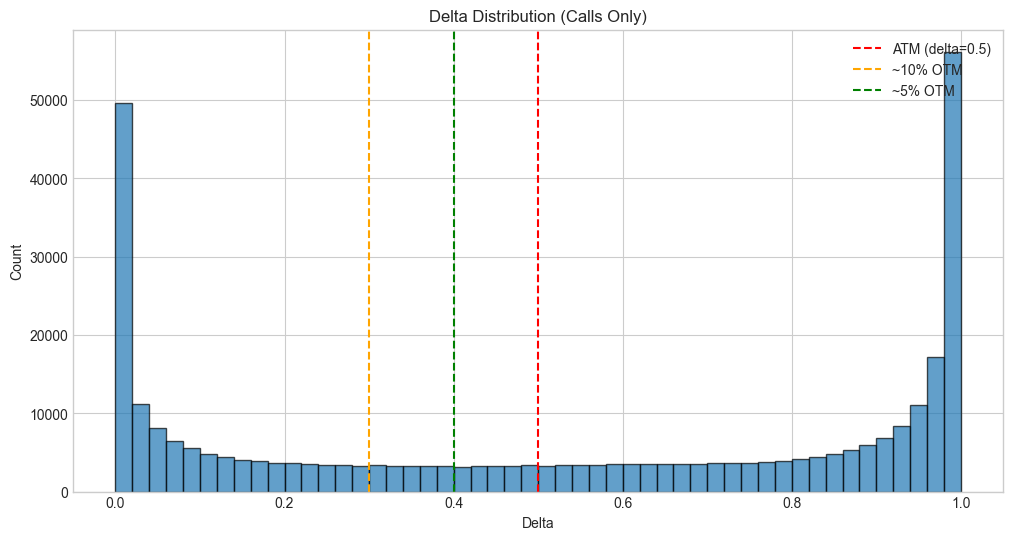

In [16]:
# Delta distribution (moneyness proxy)
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(calls['delta'].dropna(), bins=50, edgecolor='black', alpha=0.7)
ax.set_xlabel('Delta')
ax.set_ylabel('Count')
ax.set_title('Delta Distribution (Calls Only)')
ax.axvline(x=0.5, color='red', linestyle='--', label='ATM (delta=0.5)')
ax.axvline(x=0.3, color='orange', linestyle='--', label='~10% OTM')
ax.axvline(x=0.4, color='green', linestyle='--', label='~5% OTM')
ax.legend()
plt.show()

## 6. Correlation Analysis

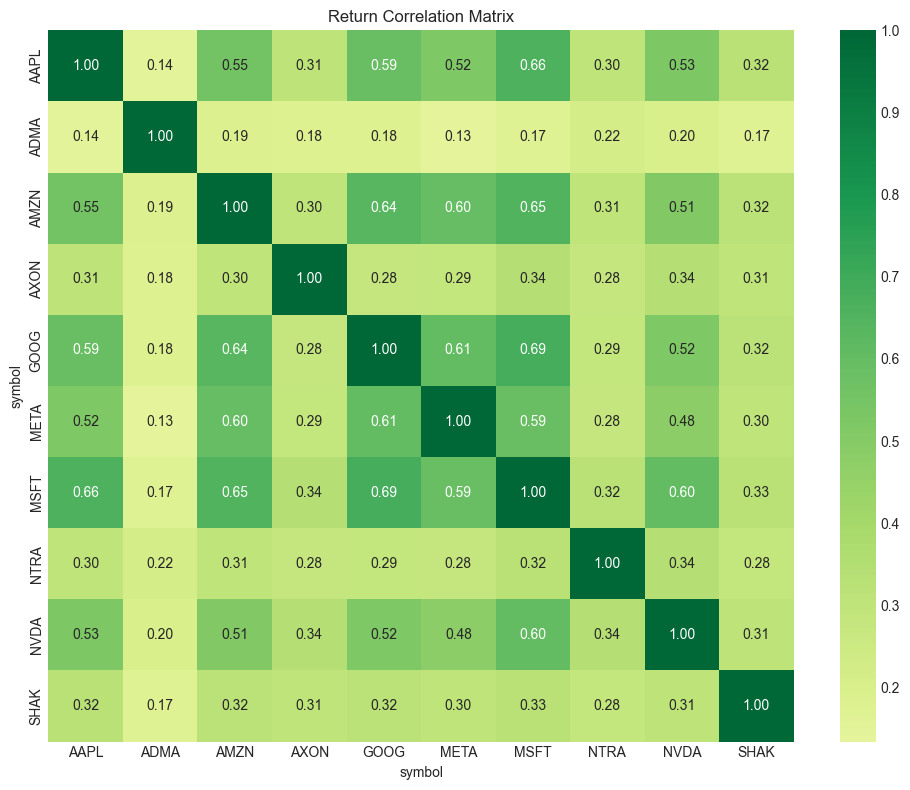

In [17]:
# Return correlation matrix
returns_pivot = daily.pivot(index='date', columns='symbol', values='return')
corr_matrix = returns_pivot.corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f', ax=ax)
ax.set_title('Return Correlation Matrix')
plt.tight_layout()
plt.show()

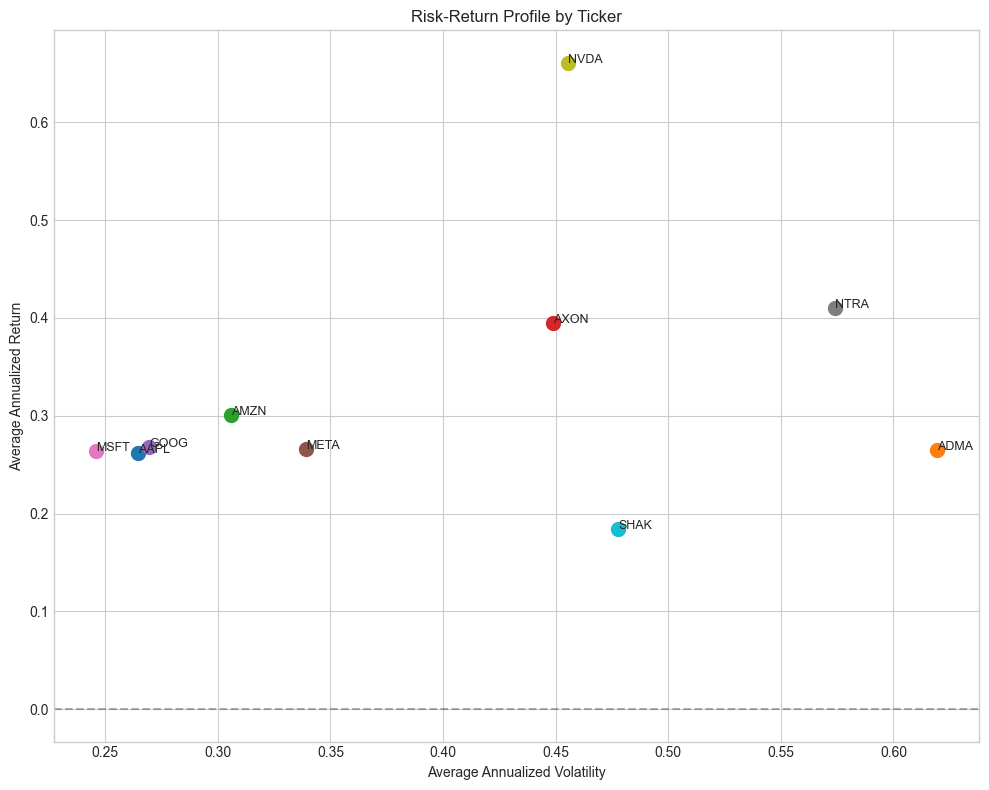

In [18]:
# Volatility vs Return scatter
fig, ax = plt.subplots(figsize=(10, 8))

for ticker in daily['symbol'].unique():
    subset = daily[daily['symbol'] == ticker]
    mean_return = subset['return'].mean() * 252  # Annualized
    mean_vol = subset['volatility_30d'].mean()
    ax.scatter(mean_vol, mean_return, s=100, label=ticker)
    ax.annotate(ticker, (mean_vol, mean_return), fontsize=9)

ax.set_xlabel('Average Annualized Volatility')
ax.set_ylabel('Average Annualized Return')
ax.set_title('Risk-Return Profile by Ticker')
ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Sector Analysis

In [19]:
# Sector breakdown
print("Sector Breakdown:")
print(overview[['symbol', 'sector', 'industry']])

Sector Breakdown:
  symbol                  sector                        industry
0   ADMA              HEALTHCARE                   BIOTECHNOLOGY
1   NTRA              HEALTHCARE          DIAGNOSTICS & RESEARCH
2   AXON             INDUSTRIALS             AEROSPACE & DEFENSE
3   SHAK       CONSUMER CYCLICAL                     RESTAURANTS
4   AAPL              TECHNOLOGY            CONSUMER ELECTRONICS
5   MSFT              TECHNOLOGY       SOFTWARE - INFRASTRUCTURE
6   NVDA              TECHNOLOGY                  SEMICONDUCTORS
7   AMZN       CONSUMER CYCLICAL                 INTERNET RETAIL
8   GOOG  COMMUNICATION SERVICES  INTERNET CONTENT & INFORMATION
9   META  COMMUNICATION SERVICES  INTERNET CONTENT & INFORMATION


In [20]:
# Merge sector info with returns
sector_map = overview.set_index('symbol')['sector'].to_dict()
daily['sector'] = daily['symbol'].map(sector_map)

# Average return by sector
sector_returns = daily.groupby('sector')['return'].mean() * 252
print("\nAnnualized Return by Sector:")
print(sector_returns.round(4))


Annualized Return by Sector:
sector
COMMUNICATION SERVICES    0.2671
CONSUMER CYCLICAL         0.2427
HEALTHCARE                0.3358
INDUSTRIALS               0.3945
TECHNOLOGY                0.3955
Name: return, dtype: float64


## 8. Key Insights Summary

In [22]:
# Highest volatility stocks
vol_ranking = daily.groupby('symbol')['volatility_30d'].mean().sort_values(ascending=False)
print(f"\n Highest Volatility Stocks:")
print(f"   {vol_ranking.index[0]}: {vol_ranking.iloc[0]:.2%}")
print(f"   {vol_ranking.index[1]}: {vol_ranking.iloc[1]:.2%}")
print(f"   {vol_ranking.index[2]}: {vol_ranking.iloc[2]:.2%}")



 Highest Volatility Stocks:
   ADMA: 61.94%
   NTRA: 57.41%
   SHAK: 47.78%


In [23]:
# Best risk-adjusted returns
print(f"\n Best Sharpe Ratios:")
print(return_stats['sharpe'].sort_values(ascending=False).head(3))


 Best Sharpe Ratios:
symbol
NVDA    1.34
GOOG    0.96
MSFT    0.94
Name: sharpe, dtype: float64


In [24]:
# Most correlated pairs
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1]  # Remove self-correlation
print(f"\n Highest Correlated Pairs:")
print(corr_pairs.head(3))


 Highest Correlated Pairs:
symbol  symbol
MSFT    GOOG      0.685461
GOOG    MSFT      0.685461
MSFT    AAPL      0.663181
dtype: float64


In [25]:
# Options data coverage
print(f"\n Options Data:")
print(f"   Total call contracts: {len(calls):,}")
print(f"   Date range: {calls['trade_date'].min()} to {calls['trade_date'].max()}")
print(f"   Avg implied vol: {calls['implied_vol'].mean():.2%}")


 Options Data:
   Total call contracts: 328,707
   Date range: 2015-02-02 00:00:00 to 2025-12-01 00:00:00
   Avg implied vol: 42.48%


## 9. Save Data

In [26]:
# Save daily with returns and volatility for feature engineering
daily.to_parquet(PROCESSED / 'daily_with_returns.parquet', index=False)
print("Saved daily data with returns and volatility.")

Saved daily data with returns and volatility.
